In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
basketball = pd.read_excel("/Users/shaammadhvani/Documents/SJSU/Grad/Fall 2024/Math 251/Project/basketball.xlsx")
#read in the data

In [3]:
basketball.head() #check the head of the data

,Name,Season,Age,Tm,Lg,Pos,G,GS,MP,FG,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,Stephen Curry,2009-10,21,GSW,NBA,PG,80,77.0,36.2,6.6,...,0.6,3.9,4.5,5.9,1.9,0.2,3.0,3.2,17.5,ROY-2
1,Stephen Curry,2010-11,22,GSW,NBA,PG,74,74.0,33.6,6.8,...,0.7,3.2,3.9,5.8,1.5,0.3,3.1,3.1,18.6,NaN
2,Stephen Curry,2011-12,23,GSW,NBA,PG,26,23.0,28.2,5.6,...,0.6,2.8,3.4,5.3,1.5,0.3,2.5,2.4,14.7,NaN
3,Stephen Curry,2012-13,24,GSW,NBA,PG,78,78.0,38.2,8.0,...,0.8,3.3,4.0,6.9,1.6,0.2,3.1,2.5,22.9,"MVP-11,MIP-8"
4,Stephen Curry,2013-14,25,GSW,NBA,PG,78,78.0,36.5,8.4,...,0.6,3.7,4.3,8.5,1.6,0.2,3.8,2.5,24.0,"MVP-6,NBA2,AS"


In [4]:
basketball.shape #check dimensions

(1235, 32)

In [5]:
basketball.dtypes #check the data types

Name       object
Season     object
Age         int64
Tm         object
Lg         object
Pos        object
G           int64
GS        float64
MP        float64
FG        float64
FGA       float64
FG%       float64
3P        float64
3PA       float64
3P%       float64
2P        float64
2PA       float64
2P%       float64
eFG%      float64
FT        float64
FTA       float64
FT%       float64
ORB       float64
DRB       float64
TRB       float64
AST       float64
STL       float64
BLK       float64
TOV       float64
PF        float64
PTS       float64
Awards     object
dtype: object

## DATA CLEANING

In [6]:
basketball['G'] = basketball['G'].astype(float) #change 'G' to a float to keep it consistent
#with the other numerical columns

In [7]:
print(basketball.columns) #check the column names

Index(['Name', 'Season', 'Age', 'Tm', 'Lg', 'Pos', 'G', 'GS', 'MP', 'FG',
       'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT',
       'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF',
       'PTS', 'Awards'],
      dtype='object')


In [8]:
basketball.shape #check dimension of data

(1235, 32)

In [9]:
basketball = basketball[basketball['G']>=41] #filter based on at least 41 games played (half the season)

In [10]:
basketball = basketball[basketball['MP']>=15] #filter based on at least 15 minutes played per game

In [11]:
sum(basketball['FG%'] != basketball['FG']/basketball['FGA']) #FG% must be the the ratio of makes and attempts
#not the case here

1119

In [12]:
basketball['FG%'] = basketball['FG']/basketball['FGA'] #make the percentage the ratio necessary

In [13]:
sum(basketball['FG%'] != basketball['FG']/basketball['FGA']) #now it works!

0

In [14]:
sum(basketball['3P%'] != basketball['3P']/basketball['3PA']) #3P% must be the the ratio of makes and attempts
#not the case here

1087

In [15]:
basketball['3P%'] = basketball['3P']/basketball['3PA'] #make the percentage the ratio necessary

In [16]:
sum(basketball['3P%'] != basketball['3P']/basketball['3PA']) #still have 120 mismatches, let us investigate

105

In [17]:
mismatches_3 = basketball[basketball['3P%'] != basketball['3P']/basketball['3PA']]
mismatches_3[['3P%','3P','3PA']] #makes sense for mismatches since we cannot have 0/0. However, I will force the
#'3P%' to be 0 for the sake of this project (same as saying they made 0 if they did not attempt any)

,3P%,3P,3PA
179,NaN,0.0,0.0
180,NaN,0.0,0.0
195,NaN,0.0,0.0
196,NaN,0.0,0.0
197,NaN,0.0,0.0
...,...,...,...
1104,NaN,0.0,0.0
1105,NaN,0.0,0.0
1111,NaN,0.0,0.0
1113,NaN,0.0,0.0


In [18]:
basketball.loc[basketball['3P%'] != basketball['3P'] / basketball['3PA'], '3P%'] = 0 #set those values to 0

In [19]:
sum(basketball['2P%'] != basketball['2P']/basketball['2PA']) #2P% must be the the ratio of makes and attempts
#not the case here

1118

In [20]:
basketball['2P%'] = basketball['2P']/basketball['2PA'] #make the percentage the ratio necessary

In [21]:
sum(basketball['2P%'] != basketball['2P']/basketball['2PA']) #now it works!

0

In [22]:
sum(basketball['FT%'] != basketball['FT']/basketball['FTA']) #2P% must be the the ratio of makes and attempts
#not the case here

1125

In [23]:
basketball['FT%'] = basketball['FT']/basketball['FTA'] #make the percentage the ratio necessary

In [24]:
sum(basketball['FT%'] != basketball['FT']/basketball['FTA']) #now it works!

0

In [25]:
sum(basketball['eFG%'] != sum((basketball['3P']/2) + basketball['FG'])/basketball['FGA']) #eFG% must be the the
#ratio seen on the right of the code, not the case here

1128

In [26]:
basketball['eFG%'] = (basketball['3P']/2 + basketball['FG'])/basketball['FGA'] #make the percentage the
#ratio necessary

In [27]:
sum(basketball['eFG%'] != (basketball['3P']/2 + basketball['FG'])/basketball['FGA']) #now it works!

0

In [28]:
basketball['MVP'] = basketball['Awards'].str.contains(r'\bMVP-1\b', na=False).astype(int) #make a column for if
#player won MVP or not from Awards column

In [29]:
basketball['AS'] = basketball['Awards'].str.contains('AS', na=False).astype(int) #make a column for if player made
#all star game or not from Awards column

In [30]:
basketball = basketball.drop(columns=['Season', 'Age', 'Lg', 'GS', 'FG', 'FGA',
                                      '3P', '3PA', '2P', '2PA', 'FT', 'FTA', 'ORB', 'DRB', 'Awards'])
#drop columns we do not think are great for the analysis or we know to be linear combinations of other columns

In [31]:
basketball.head() #check the head to see progress

,Name,Tm,Pos,G,MP,FG%,3P%,2P%,eFG%,FT%,TRB,AST,STL,BLK,TOV,PF,PTS,MVP,AS
0,Stephen Curry,GSW,PG,80.0,36.2,0.461538,0.437500,0.473684,0.534965,0.880000,4.5,5.9,1.9,0.2,3.0,3.2,17.5,0,0
1,Stephen Curry,GSW,PG,74.0,33.6,0.478873,0.434783,0.500000,0.549296,0.935484,3.9,5.8,1.5,0.3,3.1,3.1,18.6,0,0
3,Stephen Curry,GSW,PG,78.0,38.2,0.449438,0.454545,0.445545,0.547753,0.918919,4.0,6.9,1.6,0.2,3.1,2.5,22.9,0,0
4,Stephen Curry,GSW,PG,78.0,36.5,0.474576,0.417722,0.510204,0.567797,0.866667,4.3,8.5,1.6,0.2,3.8,2.5,24.0,0,1
5,Stephen Curry,GSW,PG,80.0,32.7,0.488095,0.444444,0.528736,0.595238,0.928571,4.3,7.7,2.0,0.2,3.1,2.0,23.8,1,1


In [32]:
basketball[['FG%', '3P%','2P%','eFG%','FT%']] = basketball[['FG%', '3P%','2P%','eFG%','FT%']].round(3)
#round the long decimal places from the percentage columns to two decimal places

In [33]:
basketball.head() #much better!

,Name,Tm,Pos,G,MP,FG%,3P%,2P%,eFG%,FT%,TRB,AST,STL,BLK,TOV,PF,PTS,MVP,AS
0,Stephen Curry,GSW,PG,80.0,36.2,0.462,0.438,0.474,0.535,0.880,4.5,5.9,1.9,0.2,3.0,3.2,17.5,0,0
1,Stephen Curry,GSW,PG,74.0,33.6,0.479,0.435,0.500,0.549,0.935,3.9,5.8,1.5,0.3,3.1,3.1,18.6,0,0
3,Stephen Curry,GSW,PG,78.0,38.2,0.449,0.455,0.446,0.548,0.919,4.0,6.9,1.6,0.2,3.1,2.5,22.9,0,0
4,Stephen Curry,GSW,PG,78.0,36.5,0.475,0.418,0.510,0.568,0.867,4.3,8.5,1.6,0.2,3.8,2.5,24.0,0,1
5,Stephen Curry,GSW,PG,80.0,32.7,0.488,0.444,0.529,0.595,0.929,4.3,7.7,2.0,0.2,3.1,2.0,23.8,1,1


In [34]:
basketball.dtypes #check the data types again

Name     object
Tm       object
Pos      object
G       float64
MP      float64
FG%     float64
3P%     float64
2P%     float64
eFG%    float64
FT%     float64
TRB     float64
AST     float64
STL     float64
BLK     float64
TOV     float64
PF      float64
PTS     float64
MVP       int64
AS        int64
dtype: object

In [35]:
basketball[['MVP','AS']] = basketball[['MVP','AS']].astype(object) #change MVP and AS to objects since they are
#not numerical

In [36]:
basketball.dtypes #check the data types again

Name     object
Tm       object
Pos      object
G       float64
MP      float64
FG%     float64
3P%     float64
2P%     float64
eFG%    float64
FT%     float64
TRB     float64
AST     float64
STL     float64
BLK     float64
TOV     float64
PF      float64
PTS     float64
MVP      object
AS       object
dtype: object

In [37]:
print(basketball.columns)

Index(['Name', 'Tm', 'Pos', 'G', 'MP', 'FG%', '3P%', '2P%', 'eFG%', 'FT%',
       'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'MVP', 'AS'],
      dtype='object')


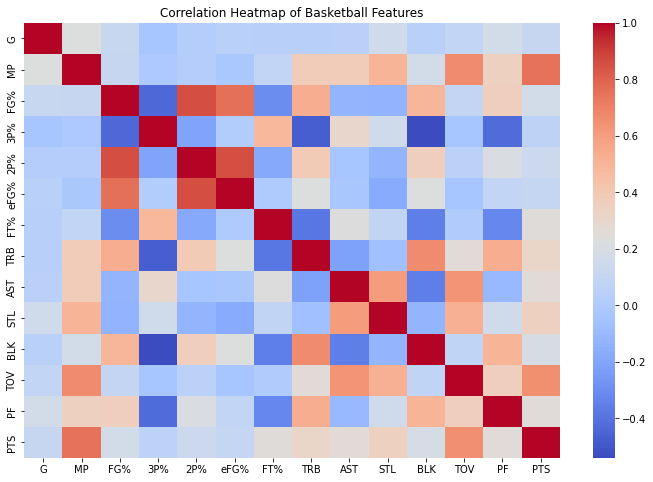

In [38]:
plt.figure(figsize=(12, 8))
sns.heatmap(basketball[['G', 'MP', 'FG%', '3P%', '2P%', 'eFG%', 'FT%',
                        'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']].corr(method='pearson'),cmap='coolwarm')
plt.title('Correlation Heatmap of Basketball Features')
plt.show()
#create heat map to check for correlation, see if we should eliminate additional columns

In [39]:
basketball = basketball.drop(columns=['FG%','eFG%','MP']) #drop highly correlated columns from heatmap we
#see as unnecessary

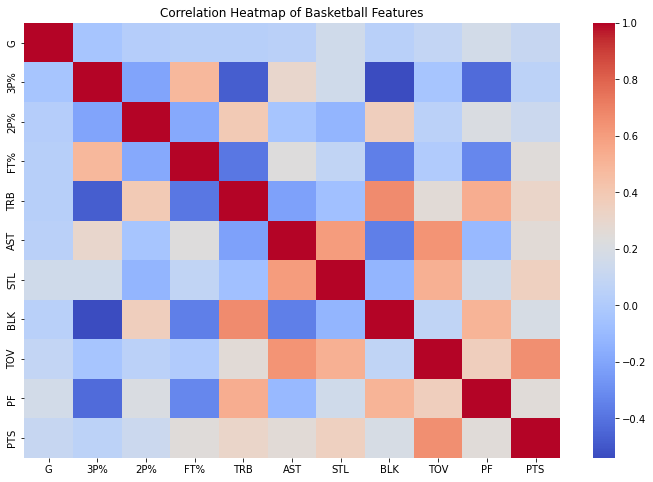

In [40]:
plt.figure(figsize=(12, 8))
sns.heatmap(basketball[['G', '3P%', '2P%', 'FT%',
                        'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']].corr(method='pearson'),cmap='coolwarm')
plt.title('Correlation Heatmap of Basketball Features')
plt.show()
#show the final heatmap

In [41]:
basketball.head() #check head again

,Name,Tm,Pos,G,3P%,2P%,FT%,TRB,AST,STL,BLK,TOV,PF,PTS,MVP,AS
0,Stephen Curry,GSW,PG,80.0,0.438,0.474,0.880,4.5,5.9,1.9,0.2,3.0,3.2,17.5,0,0
1,Stephen Curry,GSW,PG,74.0,0.435,0.500,0.935,3.9,5.8,1.5,0.3,3.1,3.1,18.6,0,0
3,Stephen Curry,GSW,PG,78.0,0.455,0.446,0.919,4.0,6.9,1.6,0.2,3.1,2.5,22.9,0,0
4,Stephen Curry,GSW,PG,78.0,0.418,0.510,0.867,4.3,8.5,1.6,0.2,3.8,2.5,24.0,0,1
5,Stephen Curry,GSW,PG,80.0,0.444,0.529,0.929,4.3,7.7,2.0,0.2,3.1,2.0,23.8,1,1


## EXPLORATORY DATA ANALYSIS

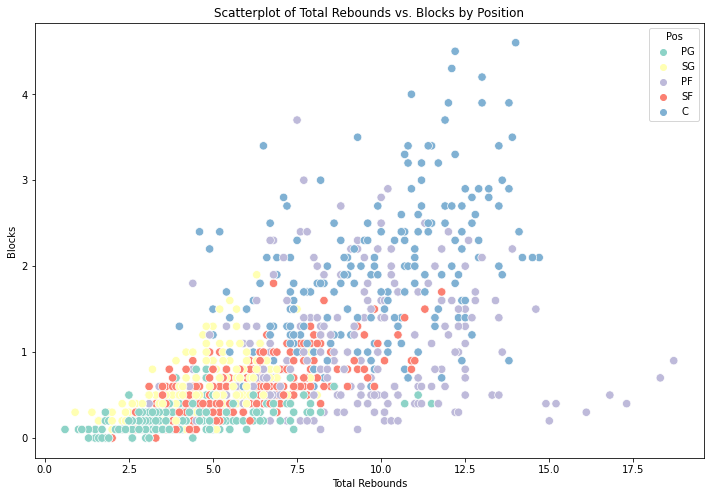

In [42]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='TRB', y='BLK', hue='Pos', data=basketball, palette='Set3', s = 70)
plt.title('Scatterplot of Total Rebounds vs. Blocks by Position')
plt.xlabel('Total Rebounds')
plt.ylabel('Blocks')
plt.show()

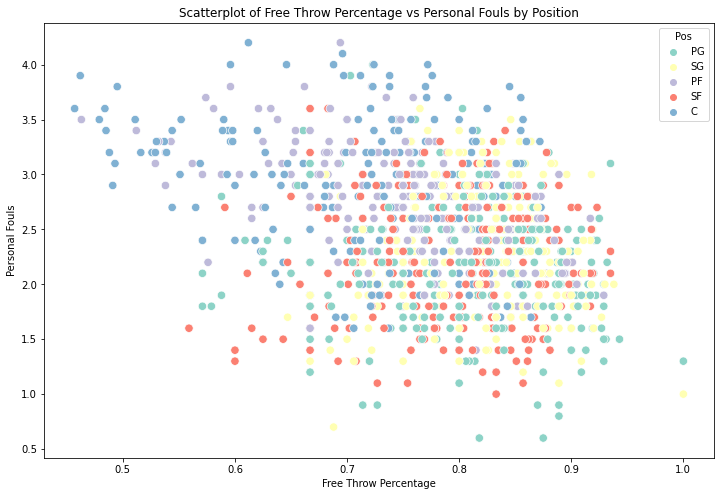

In [43]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='FT%', y='PF', hue='Pos', data=basketball, palette='Set3', s = 70)
plt.title("Scatterplot of Free Throw Percentage vs Personal Fouls by Position")
plt.xlabel('Free Throw Percentage')
plt.ylabel('Personal Fouls')
plt.show()

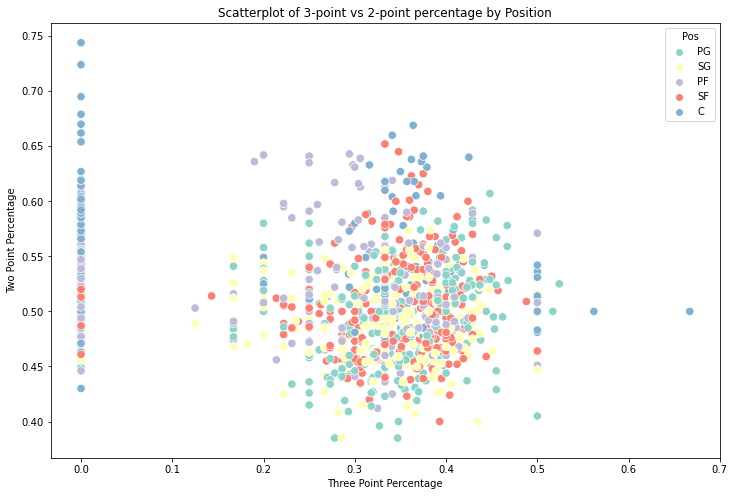

In [44]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='3P%', y='2P%', hue='Pos', data=basketball, palette='Set3', s = 70)
plt.title("Scatterplot of 3-point vs 2-point percentage by Position")
plt.xlabel('Three Point Percentage')
plt.ylabel('Two Point Percentage')
plt.show()

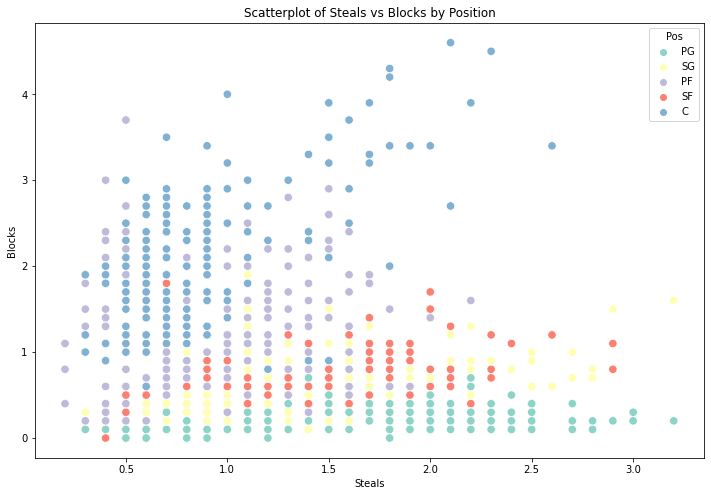

In [45]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='STL', y='BLK', hue='Pos', data=basketball, palette='Set3', s = 70)
plt.title("Scatterplot of Steals vs Blocks by Position")
plt.xlabel('Steals')
plt.ylabel('Blocks')
plt.show()

In [46]:
basketball['STL'].value_counts() #there are many repeated values on the x-axis, hence the vertical lines
basketball['BLK'].value_counts() #there are many repeated values on the y-axis as well, hence the horizontal lines

0.2    132
0.3    128
0.4    109
0.1     96
0.5     87
0.6     76
0.7     56
0.8     52
1.0     35
0.9     34
1.1     29
1.3     26
1.2     23
1.4     21
1.5     20
1.6     18
1.7     17
0.0     16
2.1     15
1.9     15
2.0     15
1.8     15
2.4     14
2.3     12
2.2     10
2.5      9
2.7      8
2.9      6
3.4      5
2.6      4
2.8      4
3.0      4
3.2      3
3.9      3
3.3      2
3.7      2
3.5      2
4.5      1
4.0      1
4.6      1
4.3      1
4.2      1
Name: BLK, dtype: int64

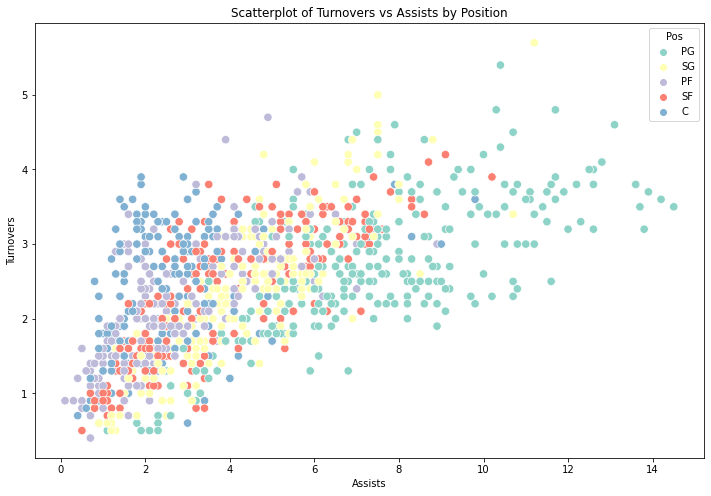

In [47]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='AST', y='TOV', hue='Pos', data=basketball, palette='Set3', s = 70)
plt.title("Scatterplot of Turnovers vs Assists by Position")
plt.xlabel('Assists')
plt.ylabel('Turnovers')
plt.show()

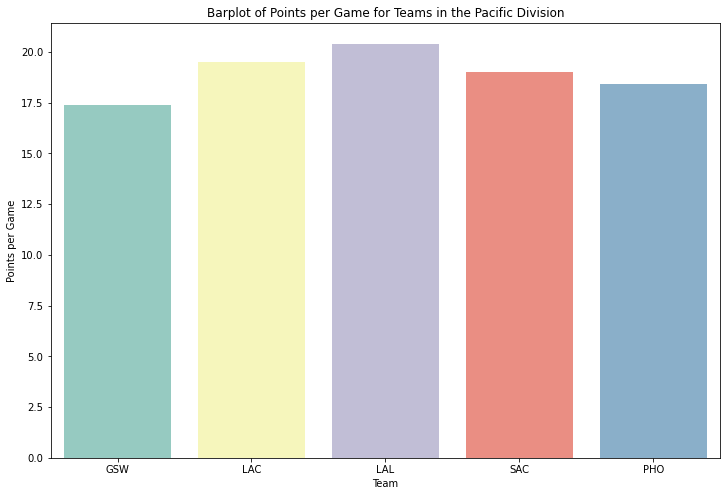

In [48]:
grouped_teams = basketball.groupby('Tm')['PTS'].mean().reset_index().round(1).set_index('Tm')
grouped_teams = grouped_teams.loc[['GSW','LAC','LAL','SAC','PHO']].reset_index()
plt.figure(figsize=(12, 8))
sns.barplot(data=grouped_teams, x='Tm', y='PTS', palette='Set3', ci = None)
plt.title("Barplot of Points per Game for Teams in the Pacific Division")
plt.xlabel('Team')
plt.ylabel('Points per Game')
plt.show()

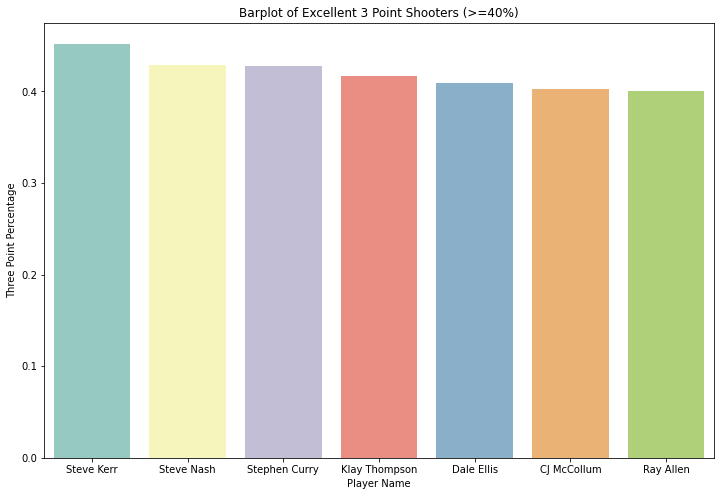

In [49]:
grouped_players = basketball.groupby('Name')['3P%'].mean().reset_index().round(3).sort_values(by = '3P%'
                                                                                              , ascending = False)
grouped_players = grouped_players[grouped_players['3P%'] >= 0.4]
plt.figure(figsize=(12, 8))
sns.barplot(data=grouped_players, x='Name', y='3P%', palette='Set3', ci = None)
plt.title("Barplot of Excellent 3 Point Shooters (>=40%)")
plt.xlabel('Player Name')
plt.ylabel('Three Point Percentage')
plt.show()

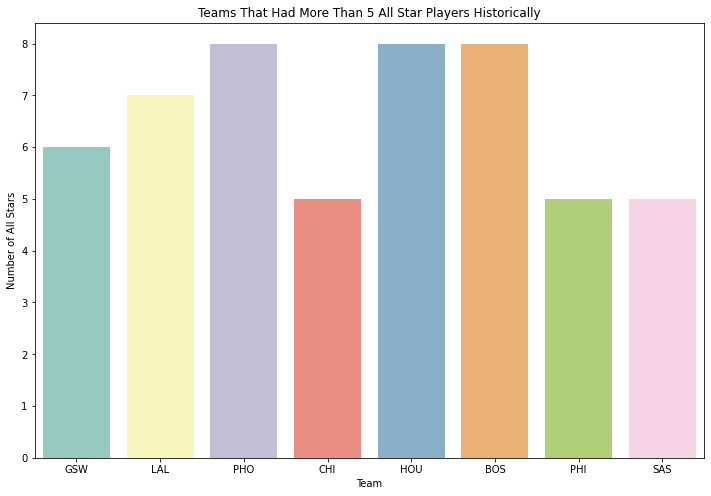

In [50]:
unique_allstars = basketball[basketball['AS'] == 1].drop_duplicates(subset=['Name', 'Tm'])
allstar_counts = unique_allstars.groupby('Tm')['AS'].sum().reset_index(name='allstar_count')
teams_with_two_allstars = allstar_counts[allstar_counts['allstar_count'] >= 5]
basketball_filtered = basketball[basketball['Tm'].isin(teams_with_two_allstars['Tm'])]
basketball_filtered = basketball_filtered.merge(allstar_counts, on='Tm', how='left')
plt.figure(figsize=(12, 8))
sns.barplot(x='Tm', y='allstar_count', data=basketball_filtered, palette='Set3',ci=None)
plt.ylabel("Number of All Stars")
plt.xlabel("Team")
plt.title("Teams That Had More Than 5 All Star Players Historically")
plt.show()

## MODEL BUILDING

In [51]:
basketball.head() #reminder of data

,Name,Tm,Pos,G,3P%,2P%,FT%,TRB,AST,STL,BLK,TOV,PF,PTS,MVP,AS
0,Stephen Curry,GSW,PG,80.0,0.438,0.474,0.880,4.5,5.9,1.9,0.2,3.0,3.2,17.5,0,0
1,Stephen Curry,GSW,PG,74.0,0.435,0.500,0.935,3.9,5.8,1.5,0.3,3.1,3.1,18.6,0,0
3,Stephen Curry,GSW,PG,78.0,0.455,0.446,0.919,4.0,6.9,1.6,0.2,3.1,2.5,22.9,0,0
4,Stephen Curry,GSW,PG,78.0,0.418,0.510,0.867,4.3,8.5,1.6,0.2,3.8,2.5,24.0,0,1
5,Stephen Curry,GSW,PG,80.0,0.444,0.529,0.929,4.3,7.7,2.0,0.2,3.1,2.0,23.8,1,1


In [52]:
from sklearn.model_selection import train_test_split

X = basketball.drop(columns=['Name', 'Tm','Pos']) #keep predictor variables in 2-d array X
y = basketball['Pos'] #move Position column (response) to a separate 1-d array

# Split the data into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12)

from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report #import relevant
                                                                                                #metrics

In [53]:
#KNN

from sklearn.neighbors import KNeighborsClassifier #import KNN model

knn = KNeighborsClassifier(n_neighbors = 4) #establish KNN model with 5 nearest neighbors
#10 and above gives a worse metric for accuracy, precision, and recall
knn.fit(X_train, y_train) #fit the model to training data

y_pred_knn = knn.predict(X_test) #predict on the test data

accuracy_knn = accuracy_score(y_test, y_pred_knn) #calculate accuracy
precision_weighted_knn = precision_score(y_test, y_pred_knn, average='weighted') #calculate weighted precision to
                                                                        #account for potential class imbalance
recall_weighted_knn = recall_score(y_test, y_pred_knn, average='weighted') #calculate weighted recall to account
                                                                        #for potential class imbalance

print(f"Accuracy: {accuracy_knn:.4f}") #print the results
print(f"Precision: {precision_weighted_knn:.4f}")
print(f"Recall: {recall_weighted_knn:.4f}")
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.6047
Precision: 0.6041
Recall: 0.6047
              precision    recall  f1-score   support

           C       0.51      0.72      0.60        54
          PF       0.58      0.40      0.47        65
          PG       0.79      0.85      0.82        82
          SF       0.58      0.54      0.56        79
          SG       0.50      0.46      0.48        59

    accuracy                           0.60       339
   macro avg       0.59      0.60      0.59       339
weighted avg       0.60      0.60      0.60       339



In [54]:
#Logistic

from sklearn.linear_model import LogisticRegression #import Logistic Regression model

lg = LogisticRegression(multi_class='multinomial', solver='newton-cg', max_iter=29, tol=0.0001) #establish Logistic model
                                                                            #with 4000 max iterations
#'lbfgs' and 'newton-cg' had the same results, ‘sag’ and ‘saga’ were lower. max_iter must start at ~3600 for
#for 'lbfgs' convergence, tolerance has no major impact
lg.fit(X_train, y_train) #fit the model to training data

y_pred_lg = lg.predict(X_test) #predict on the test data

accuracy_lg = accuracy_score(y_test, y_pred_lg) #calculate accuracy
precision_weighted_lg = precision_score(y_test, y_pred_lg, average='weighted') #calculate weighted precision to
                                                                        #account for potential class imbalance
recall_weighted_lg = recall_score(y_test, y_pred_lg, average='weighted') #calculate weighted recall to account
                                                                        #for potential class imbalance

print(f"Accuracy: {accuracy_lg:.4f}") #print the results
print(f"Precision: {precision_weighted_lg:.4f}")
print(f"Recall: {recall_weighted_lg:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lg))

Accuracy: 0.7817
Precision: 0.7816
Recall: 0.7817

Classification Report:
              precision    recall  f1-score   support

           C       0.70      0.78      0.74        54
          PF       0.72      0.66      0.69        65
          PG       0.89      0.90      0.90        82
          SF       0.81      0.81      0.81        79
          SG       0.74      0.71      0.72        59

    accuracy                           0.78       339
   macro avg       0.77      0.77      0.77       339
weighted avg       0.78      0.78      0.78       339



In [55]:
#LDA

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis #import LDA model

lda = LinearDiscriminantAnalysis(tol=0.0001) #establish LDA model
#no major parameter adjustments done here, tolerance does not have major impact on accuracy

lda.fit(X_train, y_train) #fit the model to training data

y_pred_lda = lda.predict(X_test) #predict on the test data

accuracy_lda = accuracy_score(y_test, y_pred_lda) #calculate accuracy
precision_weighted_lda = precision_score(y_test, y_pred_lda, average='weighted') #calculate weighted precision to
                                                                        #account for potential class imbalance
recall_weighted_lda = recall_score(y_test, y_pred_lda, average='weighted') #calculate weighted recall to account
                                                                        #for potential class imbalance

print(f"Accuracy: {accuracy_lda:.4f}") #print the results
print(f"Precision: {precision_weighted_lda:.4f}")
print(f"Recall: {recall_weighted_lda:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lda))

Accuracy: 0.7316
Precision: 0.7368
Recall: 0.7316

Classification Report:
              precision    recall  f1-score   support

           C       0.70      0.74      0.72        54
          PF       0.68      0.65      0.66        65
          PG       0.86      0.83      0.84        82
          SF       0.78      0.72      0.75        79
          SG       0.60      0.69      0.65        59

    accuracy                           0.73       339
   macro avg       0.72      0.73      0.72       339
weighted avg       0.74      0.73      0.73       339



In [56]:
#QDA

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis #import QDA model

qda = QuadraticDiscriminantAnalysis(tol=0.0001) #establish QDA model
#no major parameter adjustments done here, tolerance does not have major impact on accuracy

qda.fit(X_train, y_train) #fit the model to training data

y_pred_qda = qda.predict(X_test) #predict on the test data

accuracy_qda = accuracy_score(y_test, y_pred_qda) #calculate accuracy
precision_weighted_qda = precision_score(y_test, y_pred_qda, average='weighted') #calculate weighted precision to
                                                                        #account for potential class imbalance
recall_weighted_qda = recall_score(y_test, y_pred_qda, average='weighted') #calculate weighted recall to account
                                                                        #for potential class imbalance

print(f"Accuracy: {accuracy_qda:.4f}") #print the results
print(f"Precision: {precision_weighted_qda:.4f}")
print(f"Recall: {recall_weighted_qda:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_qda))

Accuracy: 0.7640
Precision: 0.7687
Recall: 0.7640

Classification Report:
              precision    recall  f1-score   support

           C       0.68      0.83      0.75        54
          PF       0.75      0.63      0.68        65
          PG       0.83      0.87      0.85        82
          SF       0.84      0.73      0.78        79
          SG       0.70      0.75      0.72        59

    accuracy                           0.76       339
   macro avg       0.76      0.76      0.76       339
weighted avg       0.77      0.76      0.76       339



In [57]:
#Naive Bayes

from sklearn.naive_bayes import GaussianNB #import Naive Bayes model

nb = GaussianNB(var_smoothing=1e-09) #establish the Naive Bayes model
#no real adjustments made here, var_smoothing doesn't help improve anymore

nb.fit(X_train, y_train) #fit the model to the training data

y_pred_nb = nb.predict(X_test) #predict on the test data

accuracy_nb = accuracy_score(y_test, y_pred_nb) #calculate accuracy
precision_weighted_nb = precision_score(y_test, y_pred_nb, average='weighted') #calculate weighted precision to
                                                                        #account for potential class imbalance
recall_weighted_nb = recall_score(y_test, y_pred_nb, average='weighted') #calculate weighted recall to account
                                                                        #for potential class imbalance

print(f"Accuracy: {accuracy_nb:.4f}") #print the results
print(f"Precision: {precision_weighted_nb:.4f}")
print(f"Recall: {recall_weighted_nb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.6254
Precision: 0.6390
Recall: 0.6254

Classification Report:
              precision    recall  f1-score   support

           C       0.62      0.65      0.64        54
          PF       0.56      0.48      0.52        65
          PG       0.87      0.80      0.84        82
          SF       0.60      0.52      0.56        79
          SG       0.46      0.66      0.55        59

    accuracy                           0.63       339
   macro avg       0.62      0.62      0.62       339
weighted avg       0.64      0.63      0.63       339



In [58]:
# Tree

from sklearn.tree import DecisionTreeClassifier #import Decision Tree model

dtree = DecisionTreeClassifier(max_depth=20) #establish the Decision Tree model

dtree.fit(X_train, y_train) #fit the model to the training data

y_pred_dtree = dtree.predict(X_test) #predict on the test data

accuracy_dtree = accuracy_score(y_test, y_pred_dtree) #calculate accuracy
precision_weighted_dtree = precision_score(y_test, y_pred_dtree, average='weighted') #calculate weighted precision to
                                                                        #account for potential class imbalance
recall_weighted_dtree = recall_score(y_test, y_pred_dtree, average='weighted') #calculate weighted recall to account
                                                                        #for potential class imbalance

print(f"Accuracy: {accuracy_dtree:.4f}") #print the results
print(f"Precision: {precision_weighted_dtree:.4f}")
print(f"Recall: {recall_weighted_dtree:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dtree))

Accuracy: 0.6726
Precision: 0.6775
Recall: 0.6726

Classification Report:
              precision    recall  f1-score   support

           C       0.63      0.78      0.69        54
          PF       0.71      0.54      0.61        65
          PG       0.82      0.79      0.81        82
          SF       0.62      0.71      0.66        79
          SG       0.56      0.51      0.53        59

    accuracy                           0.67       339
   macro avg       0.67      0.67      0.66       339
weighted avg       0.68      0.67      0.67       339



In [59]:
# RF

from sklearn.ensemble import RandomForestClassifier #import Random Forest model

rfc = RandomForestClassifier(n_estimators=200, max_depth=30) #establish the Random Forest model

rfc.fit(X_train, y_train) #fit the model to the training data

y_pred_rfc = rfc.predict(X_test) #predict on the test data

accuracy_rfc = accuracy_score(y_test, y_pred_rfc) #calculate accuracy
precision_weighted_rfc = precision_score(y_test, y_pred_rfc, average='weighted') #calculate weighted precision to
                                                                        #account for potential class imbalance
recall_weighted_rfc = recall_score(y_test, y_pred_rfc, average='weighted') #calculate weighted recall to account
                                                                        #for potential class imbalance

print(f"Accuracy: {accuracy_rfc:.4f}") #print the results
print(f"Precision: {precision_weighted_rfc:.4f}")
print(f"Recall: {recall_weighted_rfc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rfc))

Accuracy: 0.8378
Precision: 0.8436
Recall: 0.8378

Classification Report:
              precision    recall  f1-score   support

           C       0.74      0.94      0.83        54
          PF       0.90      0.68      0.77        65
          PG       0.93      0.96      0.95        82
          SF       0.83      0.85      0.84        79
          SG       0.78      0.73      0.75        59

    accuracy                           0.84       339
   macro avg       0.84      0.83      0.83       339
weighted avg       0.84      0.84      0.84       339



In [60]:
# SVM

from sklearn.svm import SVC #import SVM model

svm = SVC(C = 100, class_weight='balanced') #establish the SVM model

svm.fit(X_train, y_train) #fit the model to the training data

y_pred_svm = svm.predict(X_test) #predict on the test data

accuracy_svm = accuracy_score(y_test, y_pred_svm) #calculate accuracy
precision_weighted_svm = precision_score(y_test, y_pred_svm, average='weighted') #calculate weighted precision to
                                                                        #account for potential class imbalance
recall_weighted_svm = recall_score(y_test, y_pred_svm, average='weighted') #calculate weighted recall to account
                                                                        #for potential class imbalance

print(f"Accuracy: {accuracy_svm:.4f}") #print the results
print(f"Precision: {precision_weighted_svm:.4f}")
print(f"Recall: {recall_weighted_svm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.7758
Precision: 0.7797
Recall: 0.7758

Classification Report:
              precision    recall  f1-score   support

           C       0.73      0.80      0.76        54
          PF       0.74      0.71      0.72        65
          PG       0.91      0.87      0.89        82
          SF       0.79      0.75      0.77        79
          SG       0.68      0.75      0.71        59

    accuracy                           0.78       339
   macro avg       0.77      0.77      0.77       339
weighted avg       0.78      0.78      0.78       339



In [61]:
# Boosting

from sklearn.ensemble import AdaBoostClassifier #import Boosting model
from sklearn.tree import DecisionTreeClassifier # for base estimators

boost = AdaBoostClassifier(n_estimators=300) #establish the boost model

boost.fit(X_train, y_train) #fit the model to the training data

y_pred_boost = boost.predict(X_test) #predict on the test data

accuracy_boost = accuracy_score(y_test, y_pred_boost) #calculate accuracy
precision_weighted_boost = precision_score(y_test, y_pred_boost, average='weighted') #calculate weighted precision to
                                                                        #account for potential class imbalance
recall_weighted_boost = recall_score(y_test, y_pred_boost, average='weighted') #calculate weighted recall to account
                                                                        #for potential class imbalance

print(f"Accuracy: {accuracy_boost:.4f}") #print the results
print(f"Precision: {precision_weighted_boost:.4f}")
print(f"Recall: {recall_weighted_boost:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_boost))

Accuracy: 0.6785
Precision: 0.6784
Recall: 0.6785

Classification Report:
              precision    recall  f1-score   support

           C       0.63      0.81      0.71        54
          PF       0.74      0.43      0.54        65
          PG       0.77      0.94      0.85        82
          SF       0.63      0.68      0.65        79
          SG       0.60      0.46      0.52        59

    accuracy                           0.68       339
   macro avg       0.67      0.67      0.65       339
weighted avg       0.68      0.68      0.66       339

